# PatchSeq Cell-Type Classification — Tutorial

This notebook walks through the full pipeline using the `DATE` class and helper modules.

```
pipeline/
  data.py      ← data loading & preprocessing
  eda.py       ← exploratory data analysis plots
  models.py    ← class DATE  (perform_PCA_LR / PCA_SVM / PCA_NB / XGBoost)
  train.py     ← CV ensemble training helpers
  evaluate.py  ← confusion matrices, ROC, comparison table, McNemar test
  analysis.py  ← XGBoost feature importance, PCA loadings heatmap
```

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pipeline.models import DATE as date
from pipeline.eda import (
    plot_cell_type_distribution,
    plot_sparsity,
    plot_hvg,
    plot_umap,
    plot_marker_heatmap,
    plot_pca_scree,
)
from pipeline.evaluate import (
    plot_confusion_matrices,
    plot_roc_curves,
    model_comparison_table,
    plot_metric_bars,
    mcnemar_test,
)
from pipeline.analysis import (
    plot_xgb_feature_importance,
    plot_pca_marker_heatmap,
)

## 1. Load data & create DATE instance

`DATE` loads and preprocesses the dataset on construction.

- `log1p=True`: apply `log(1+x)` to expression values before modeling
- `log1p=False`: keep raw CPM values

- `HVG=True`: keep the top `n_hvg` highly variable genes, default `8000`
- `HVG=False`: keep all genes

In [2]:
# Option 1: use log1p + top 8000 HVGs
# d = date(data_dir='../data', log1p=True, HVG=True, n_hvg=8000)

# Option 2: use log1p + all genes
d = date(data_dir='../data', log1p=True, HVG=False)

# Option 3: raw CPM + all genes
# d = date(data_dir='../data', log1p=False, HVG=False)

expr_with_meta = d.dataset()
print(f'Dataset shape: {expr_with_meta.shape}')
expr_with_meta.head(3)

Dataset shape: (4221, 45767)


,0610005C13Rik,0610006L08Rik,0610007P14Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610009O20Rik,0610010B08Rik,0610010F05Rik,0610010K14Rik,...,n-R5s141,n-R5s142,n-R5s143,n-R5s144,n-R5s146,n-R5s149,hemisphere,donor_id,transcriptomics_batch,cell_type
PS0810_E1-50_S88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.786026,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,left,331294,BT035,Vip
PS0817_E1-50_S19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,left,331663,BT036,Sst
PS0817_E1-50_S25,0.0,0.0,0.0,4.257863,0.0,0.0,0.0,0.0,0.99288,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,right,331663,BT036,Sst


## 2. Exploratory Data Analysis

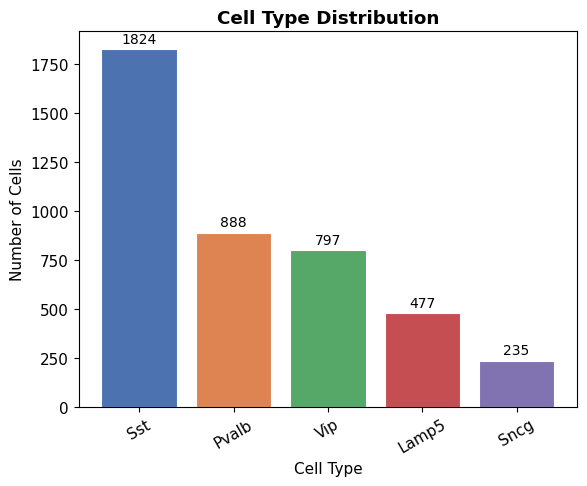

In [3]:
plot_cell_type_distribution(expr_with_meta)

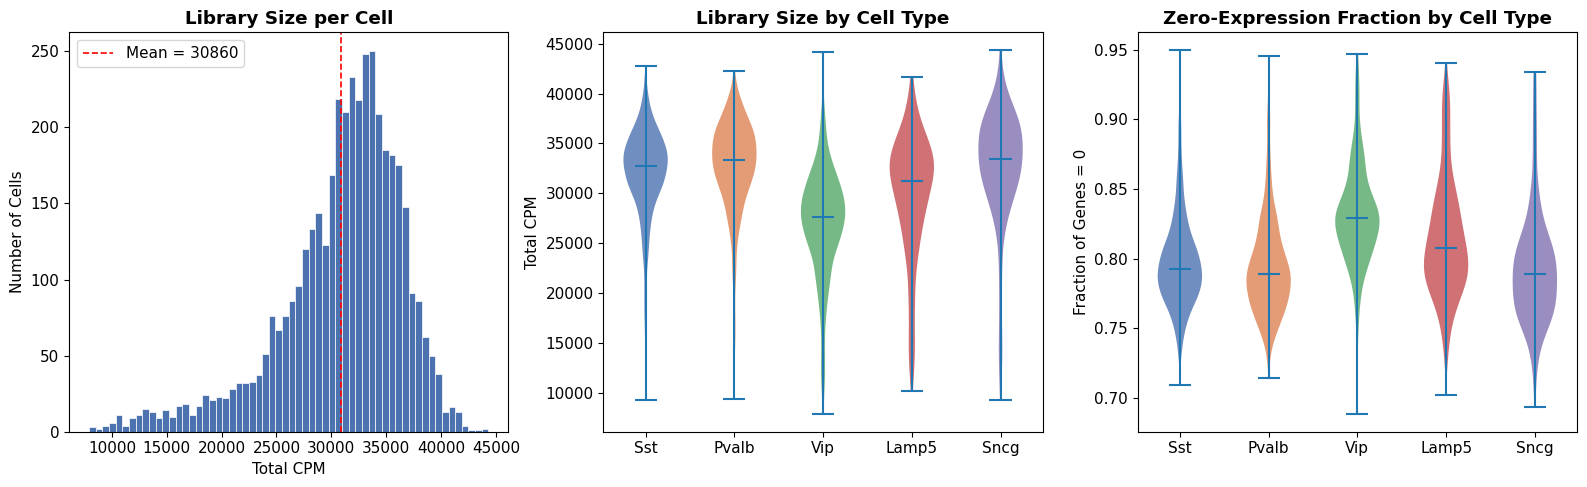

Overall zero fraction: 0.805


In [4]:
plot_sparsity(expr_with_meta)

In [5]:
# hvg_names = plot_hvg(expr_with_meta, n_hvg=8000)

In [6]:
# plot_umap(expr_with_meta)

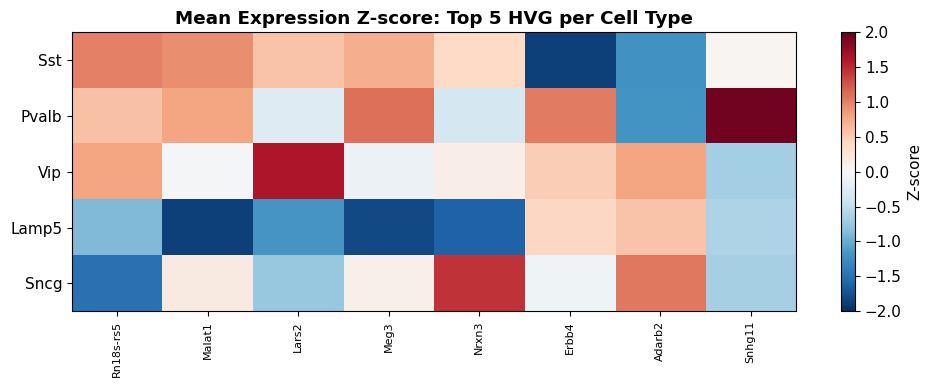

In [7]:
plot_marker_heatmap(expr_with_meta)

### PCA component selection (scree plot)

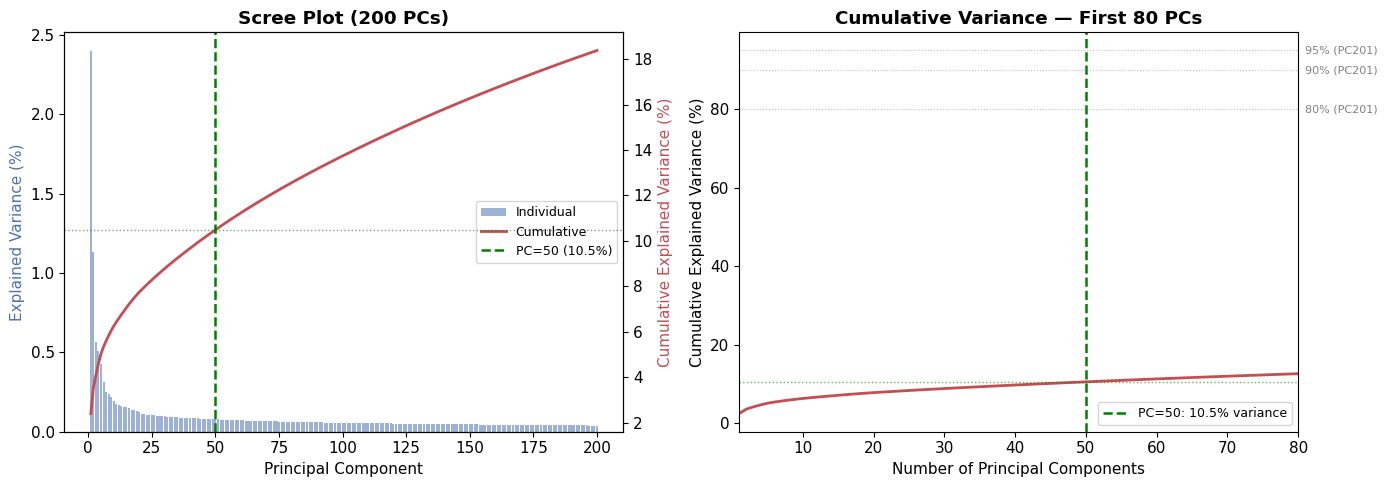

Variance explained by 50 PCs : 10.49%
PCs needed for 80% variance  : 201
PCs needed for 90% variance  : 201
PCs needed for 95% variance  : 201


In [8]:
plot_pca_scree(expr_with_meta, n_components=200, n_chosen=50)

## 3. Train models

Each method runs 3-fold donor-stratified CV and returns a results dict.  
The held-out test set is fixed across all models (`random_state=42`).

In [9]:
lr_result = d.perform_PCA_LR()
print('CV accuracy:', [f"{v:.4f}" for v in lr_result['cv_metrics']['accuracy']])
print('Test accuracy:', lr_result['test_metrics']['accuracy'])

CV accuracy: ['0.9608', '0.9558', '0.9537']
Test accuracy: 0.9684721099434115


In [10]:
svm_result = d.perform_PCA_SVM()
print('CV accuracy:', [f"{v:.4f}" for v in svm_result['cv_metrics']['accuracy']])
print('Test accuracy:', svm_result['test_metrics']['accuracy'])

CV accuracy: ['0.9598', '0.9648', '0.9698']
Test accuracy: 0.9628132578819725


In [11]:
nb_result = d.perform_PCA_NB()
print('CV accuracy:', [f"{v:.4f}" for v in nb_result['cv_metrics']['accuracy']])
print('Test accuracy:', nb_result['test_metrics']['accuracy'])

CV accuracy: ['0.7598', '0.8101', '0.5423']
Test accuracy: 0.7987065481002426


In [ ]:
xgb_result = d.perform_XGBoost(device='cpu')
print('CV accuracy:', [f"{v:.4f}" for v in xgb_result['cv_metrics']['accuracy']])
print('Test accuracy:', xgb_result['test_metrics']['accuracy'])

## 4. Evaluate & compare models

In [ ]:
results = [lr_result, svm_result, nb_result, xgb_result]

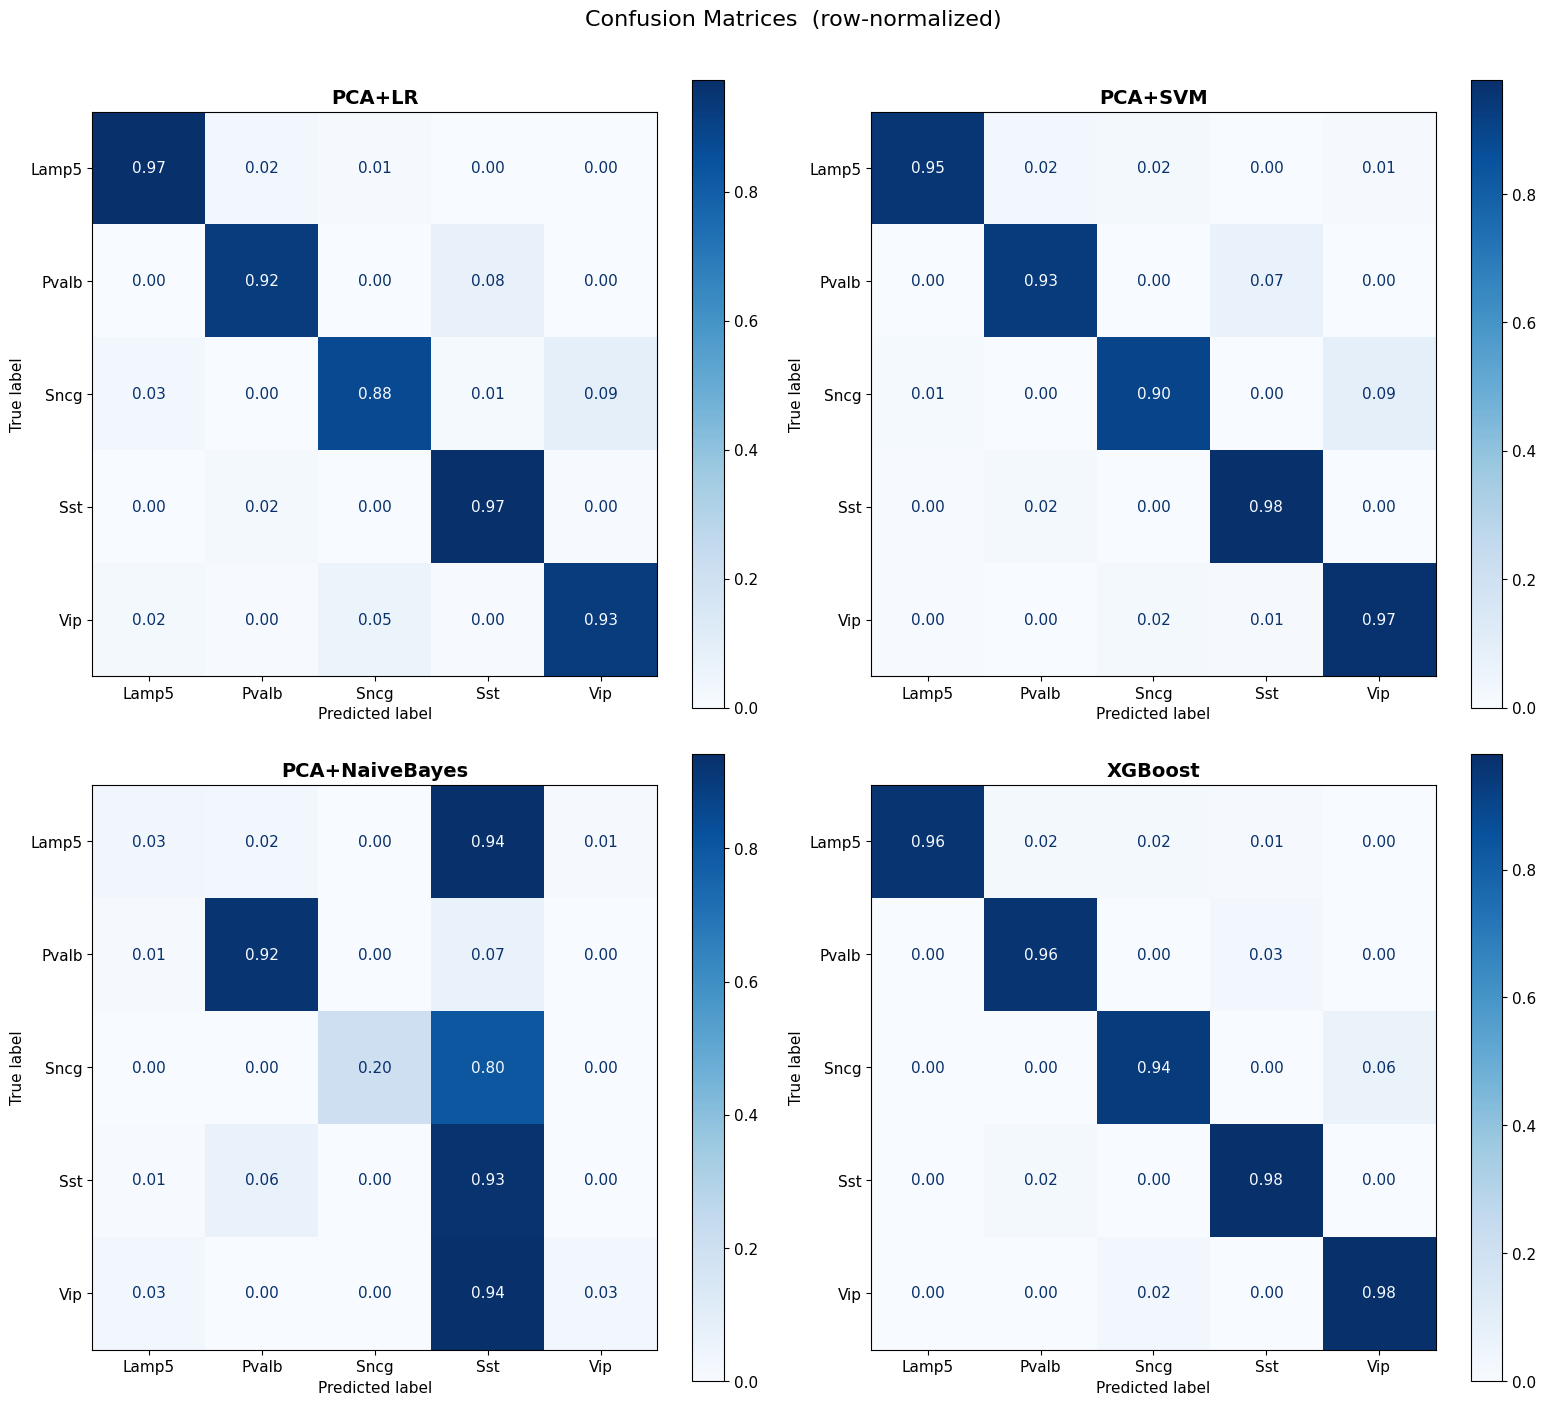

In [ ]:
plot_confusion_matrices(results)

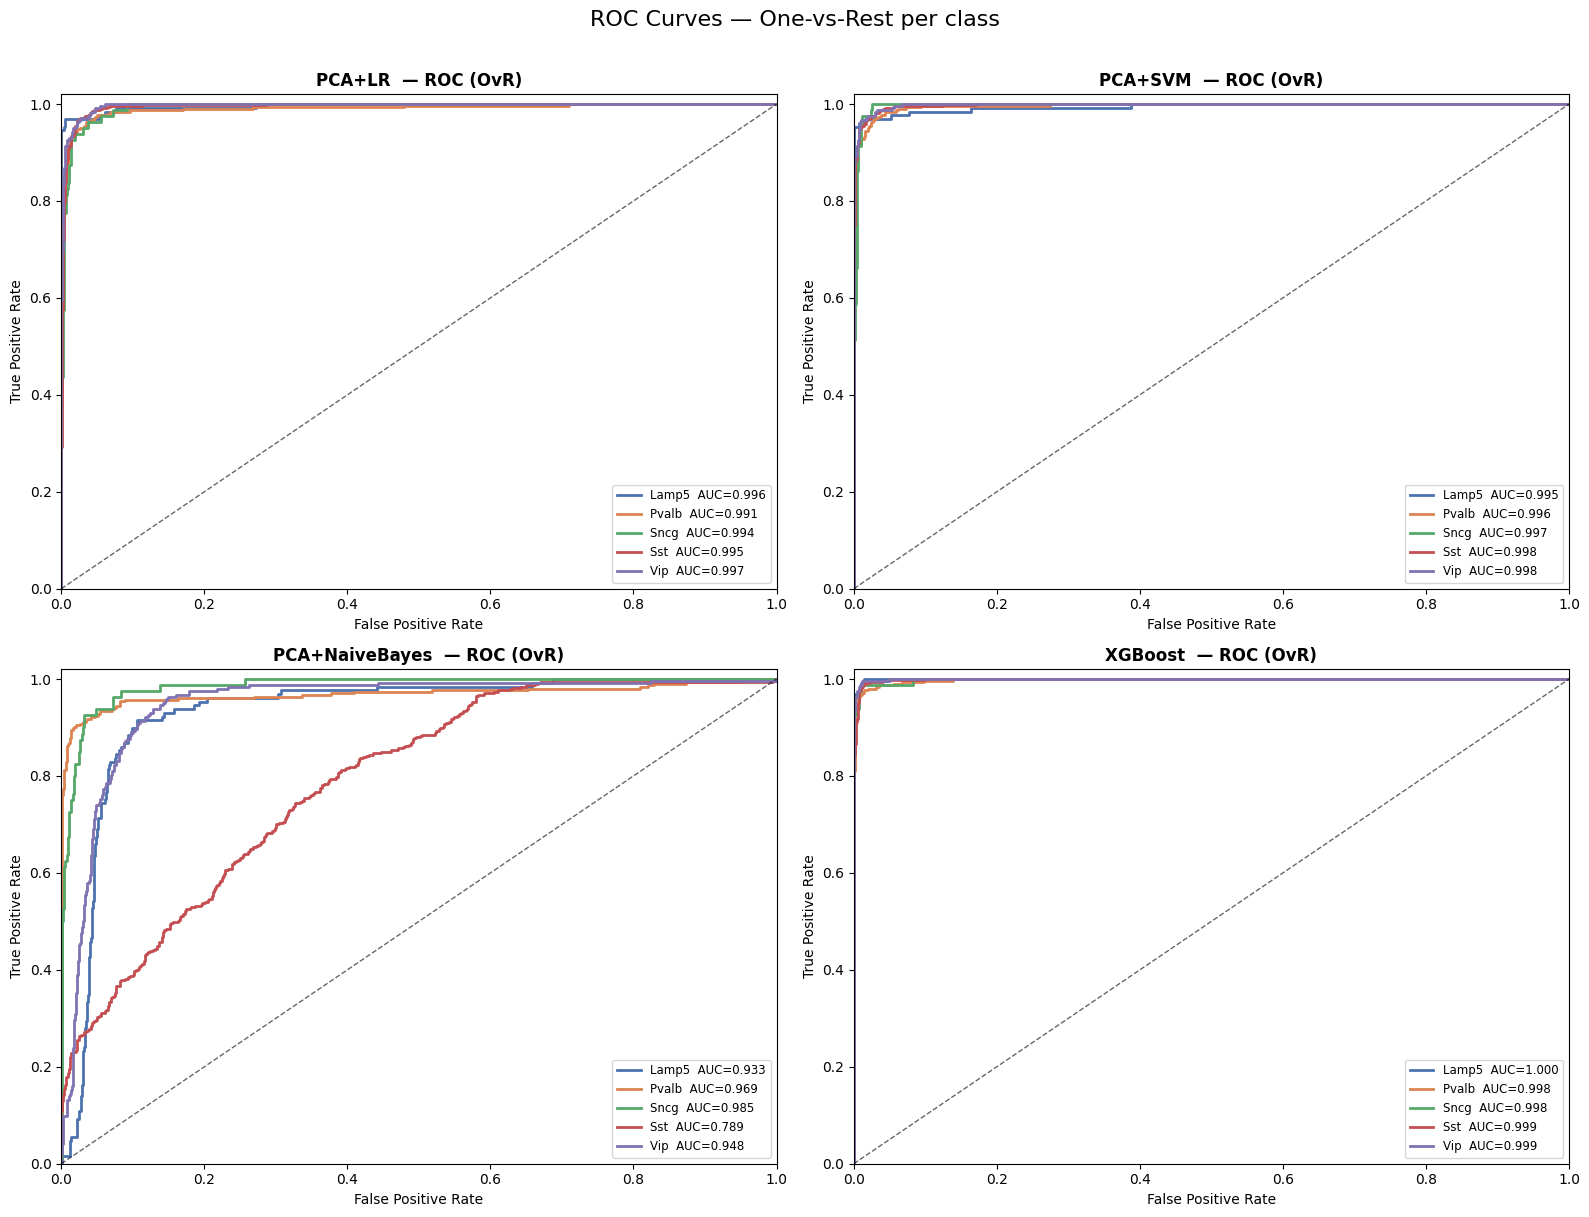

In [ ]:
plot_roc_curves(results)

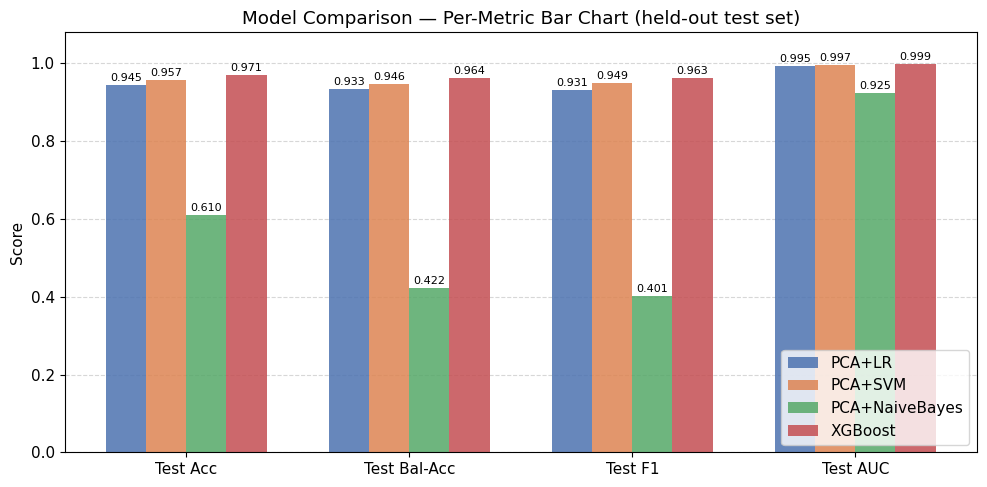

In [ ]:
plot_metric_bars(results)

In [ ]:
table = model_comparison_table(results)
num_cols = ['Test Acc', 'Test Bal-Acc', 'Test F1', 'Test AUC']
table.style.highlight_max(subset=num_cols, color='#b6f7b6', axis=0)

,CV Acc (±std),CV F1 (±std),CV AUC (±std),Test Acc,Test Bal-Acc,Test F1,Test AUC
Model,,,,,,,
PCA+LR,0.9350 ± 0.0083,0.9037 ± 0.0118,0.9861 ± 0.0036,0.945000,0.933400,0.931100,0.994500
PCA+SVM,0.9501 ± 0.0048,0.9265 ± 0.0061,0.9966 ± 0.0007,0.957200,0.946400,0.949300,0.996700
PCA+NaiveBayes,0.6032 ± 0.0318,0.4148 ± 0.0646,0.9093 ± 0.0320,0.610300,0.422100,0.400800,0.924900
XGBoost,0.9806 ± 0.0021,0.9697 ± 0.0044,0.9991 ± 0.0002,0.970900,0.963800,0.962800,0.998800


### McNemar pairwise significance test

In [ ]:
mc = mcnemar_test(results)
mc

,Model A,Model B,b (A✓ B✗),c (A✗ B✓),chi2 (cc),p-value,p_bonferroni,p_fdr_bh,sig (raw),sig (Bonf),sig (FDR)
0,PCA+LR,PCA+SVM,16,31,4.1702,0.0411,0.2466,0.0411,True,False,True
1,PCA+LR,PCA+NaiveBayes,430,16,382.4417,0.0000,0.0000,0.0000,True,True,True
2,PCA+LR,XGBoost,12,44,17.1607,0.0000,0.0000,0.0000,True,True,True
3,PCA+SVM,PCA+NaiveBayes,438,9,409.8076,0.0000,0.0000,0.0000,True,True,True
4,PCA+SVM,XGBoost,10,27,6.9189,0.0085,0.0510,0.0102,True,False,True
5,PCA+NaiveBayes,XGBoost,7,453,430.4891,0.0000,0.0000,0.0000,True,True,True


## 5. Feature analysis

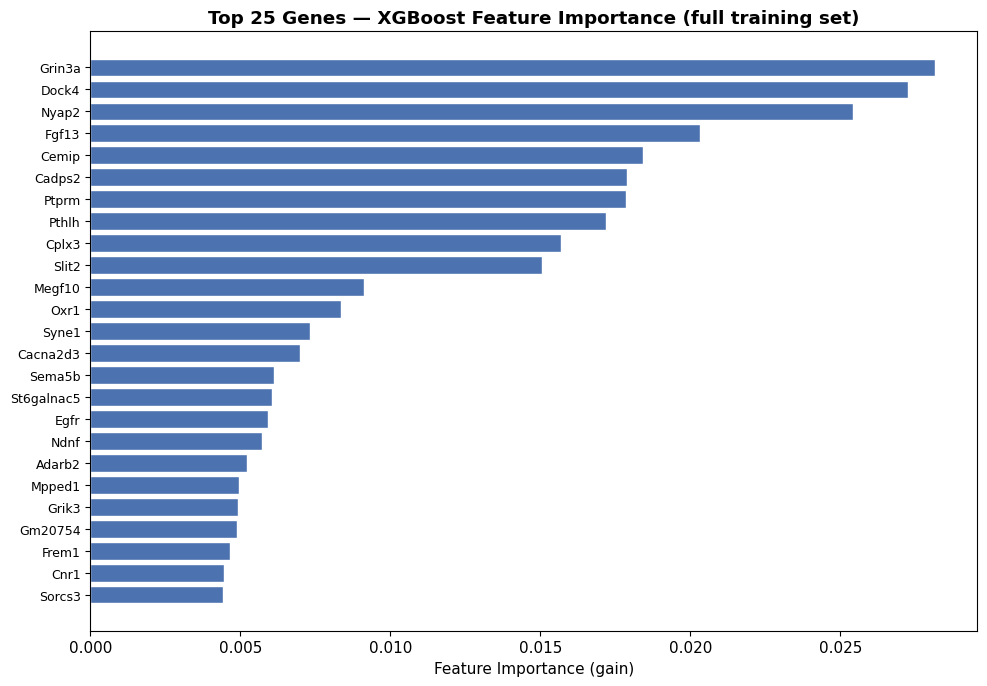

Top 25 most important genes:
  Grin3a              : 0.028146
  Dock4               : 0.027263
  Nyap2               : 0.025420
  Fgf13               : 0.020320
  Cemip               : 0.018430
  Cadps2              : 0.017876
  Ptprm               : 0.017862
  Pthlh               : 0.017189
  Cplx3               : 0.015693
  Slit2               : 0.015042
  Megf10              : 0.009126
  Oxr1                : 0.008348
  Syne1               : 0.007338
  Cacna2d3            : 0.006993
  Sema5b              : 0.006123
  St6galnac5          : 0.006057
  Egfr                : 0.005938
  Ndnf                : 0.005709
  Adarb2              : 0.005236
  Mpped1              : 0.004962
  Grik3               : 0.004922
  Gm20754             : 0.004882
  Frem1               : 0.004667
  Cnr1                : 0.004442
  Sorcs3              : 0.004413


In [ ]:
top_genes = plot_xgb_feature_importance(expr_with_meta, top_n=25, device='cuda')

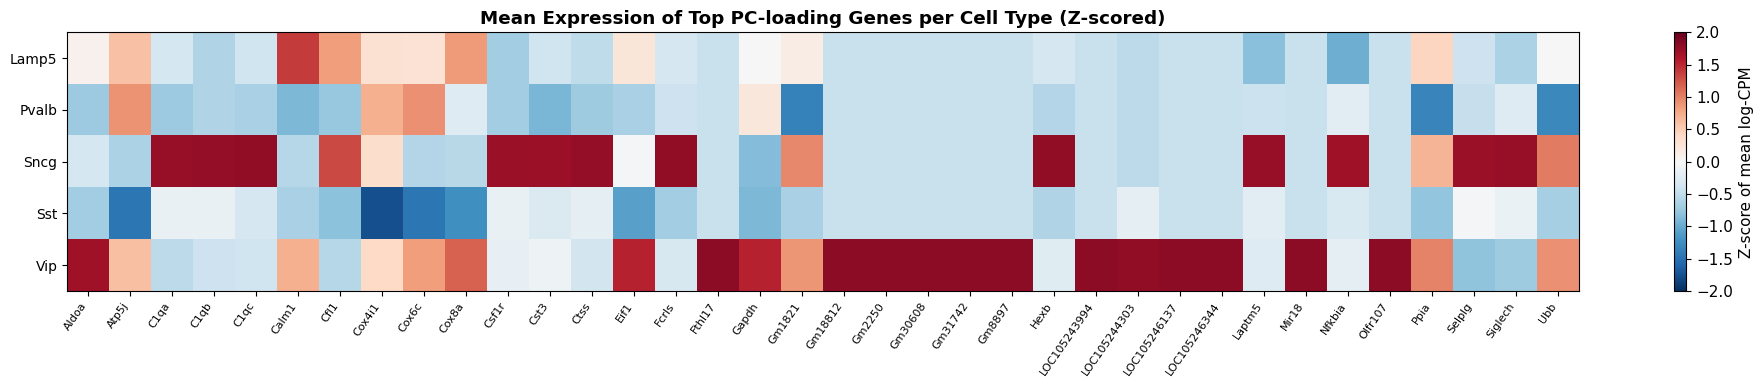

PC1 top positive genes: [np.str_('Ppia'), np.str_('Cfl1'), np.str_('Ubb'), np.str_('Gapdh'), np.str_('Eif1')]
PC2 top positive genes: [np.str_('C1qb'), np.str_('C1qc'), np.str_('Laptm5'), np.str_('C1qa'), np.str_('Ctss')]
PC3 top positive genes: [np.str_('LOC105244303'), np.str_('LOC105246344'), np.str_('Gm18812'), np.str_('LOC105246137'), np.str_('Gm31742')]


In [ ]:
plot_pca_marker_heatmap(expr_with_meta)

## 6. Per-class precision / recall

Each result dict contains a `per_class` DataFrame.

In [ ]:
for r in results:
    print(f"\n=== {r['model_name']} ===")
    display(r['per_class'])


=== PCA+LR ===


,Precision,Recall
Lamp5,0.946970,0.968992
Pvalb,0.955932,0.924590
Sncg,0.833333,0.875000
Sst,0.949290,0.972973
Vip,0.961373,0.925620



=== PCA+SVM ===


,Precision,Recall
Lamp5,0.968504,0.953488
Pvalb,0.959596,0.934426
Sncg,0.911392,0.900000
Sst,0.955285,0.977131
Vip,0.966942,0.966942



=== PCA+NaiveBayes ===


,Precision,Recall
Lamp5,0.235294,0.031008
Pvalb,0.892063,0.921311
Sncg,0.941176,0.200000
Sst,0.507955,0.929314
Vip,0.875000,0.028926



=== XGBoost ===


,Precision,Recall
Lamp5,0.984127,0.961240
Pvalb,0.967105,0.963934
Sncg,0.903614,0.937500
Sst,0.979253,0.981289
Vip,0.975207,0.975207
